## Installing and Importing Required Libraries

In [ ]:
!pip install -q python-dotenv
!pip install -q anthropic
!pip install -q cartopy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import base64
import os
import requests
import json
import re

import anthropic
from dotenv import load_dotenv
load_dotenv()

True

## Importing the Dataset

In [3]:
# Collect one year (2024) of magnitude 2.5+ events from the USGS FDSN event API.
# We request one month at a time because a single query is capped at 20,000 events,
# then concatenate the monthly slices into one DataFrame.
BASE = "https://earthquake.usgs.gov/fdsnws/event/1/query"
YEAR = 2024
MIN_MAGNITUDE = 2.5

windows = [(f"{YEAR}-{m:02d}-01", f"{YEAR}-{m + 1:02d}-01") for m in range(1, 12)]
windows.append((f"{YEAR}-12-01", f"{YEAR + 1}-01-01"))

frames = []
for start, end in windows:
    params = {
        "format": "csv",
        "starttime": start,
        "endtime": end,
        "minmagnitude": MIN_MAGNITUDE,
        "orderby": "time",
    }
    response = requests.get(BASE, params=params, timeout=90)
    frames.append(pd.read_csv(pd.io.common.StringIO(response.text)))

dataset = pd.concat(frames, ignore_index=True).drop_duplicates(subset="id").reset_index(drop=True)
dataset.to_csv("usgs_earthquakes.csv", index=False)

print(dataset.shape)

(25153, 22)


In [4]:
# Keep the columns we will analyze, parse the timestamp, and engineer features.
keep = ["time", "latitude", "longitude", "depth", "mag", "magType",
        "gap", "dmin", "rms", "place", "type", "status"]
dataset = dataset[keep].copy()

dataset["time"] = pd.to_datetime(dataset["time"], errors="coerce", utc=True)
dataset = dataset.dropna(subset=["time", "mag", "depth"]).copy()

# Derived time features. Cast the integer parts to int64 so GridDB maps them to
# LONG. The pandas .dt accessors return int32, which our type map would store as STRING.
dataset["Year"]    = dataset["time"].dt.year.astype("int64")
dataset["Month"]   = dataset["time"].dt.month.astype("int64")
dataset["Hour"]    = dataset["time"].dt.hour.astype("int64")
dataset["Weekday"] = dataset["time"].dt.day_name()

# The USGS "place" field is free text like "50 km NNW of Atka, Alaska". Derive a
# cleaner region (the part after the last comma) for grouping earthquakes by area.
def get_region(place):
    p = str(place)
    if " of " in p:
        p = p.split(" of ")[-1]
    if "," in p:
        return p.split(",")[-1].strip()
    return p.strip()

dataset["region"] = dataset["place"].apply(get_region)

# Bucket magnitude and depth into readable bands.
dataset["MagBand"] = pd.cut(
    dataset["mag"], bins=[0, 4, 5, 6, 20],
    labels=["minor (<4)", "light (4-5)", "moderate (5-6)", "strong (6+)"], right=False).astype(str)
dataset["DepthBand"] = pd.cut(
    dataset["depth"], bins=[-100, 70, 300, 1000],
    labels=["shallow (<70km)", "intermediate (70-300km)", "deep (>300km)"]).astype(str)

# Store the timestamp as a clean string and fix the column order.
dataset = dataset.sort_values("time").reset_index(drop=True)
dataset["time"] = dataset["time"].dt.strftime("%Y-%m-%d %H:%M:%S")

dataset = dataset[["time", "Year", "Month", "Hour", "Weekday", "region", "place", "type",
                   "magType", "status", "mag", "MagBand", "depth", "DepthBand",
                   "latitude", "longitude", "gap", "dmin", "rms"]]

print(dataset.shape)
dataset.head()

(25153, 19)


,time,Year,Month,Hour,Weekday,region,place,type,magType,status,mag,MagBand,depth,DepthBand,latitude,longitude,gap,dmin,rms
0,2024-01-01 00:03:15,2024,1,0,Monday,Puerto Rico,"2 km SSE of Coto Norte, Puerto Rico",earthquake,md,reviewed,3.22,minor (<4),105.150,intermediate (70-300km),18.408667,-66.4270,190.0,0.3187,0.20
1,2024-01-01 00:37:09,2024,1,0,Monday,Northern Mariana Islands,"272 km N of Saipan, Northern Mariana Islands",earthquake,mb,reviewed,4.70,light (4-5),384.941,deep (>300km),17.662500,145.4596,36.0,2.4290,0.50
2,2024-01-01 00:54:44,2024,1,0,Monday,South Sandwich Islands region,South Sandwich Islands region,earthquake,mb,reviewed,4.40,light (4-5),55.881,shallow (<70km),-57.304500,-25.8967,107.0,6.6940,0.54
3,2024-01-01 00:59:19,2024,1,0,Monday,Indonesia,"4 km SSW of Cianjur, Indonesia",earthquake,mb,reviewed,4.10,light (4-5),178.051,intermediate (70-300km),-6.859900,107.1224,97.0,0.4900,0.67
4,2024-01-01 01:05:25,2024,1,1,Monday,Chile,"7 km NNW of Taltal, Chile",earthquake,mb,reviewed,4.30,light (4-5),35.000,shallow (<70km),-25.343600,-70.5175,178.0,0.8040,0.62


## Inserting Data in GridDB

### Creating a GridDB Connection

In [5]:
username = os.environ.get("azure_username")
password = os.environ.get("azure_password")
base_url = os.environ.get("azure_base_url")


url = f"{base_url}/checkConnection"

credentials = f"{username}:{password}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()

headers = {
    'Content-Type': 'application/json',
    'Authorization': f'Basic {encoded_credentials}',
    'User-Agent': 'PostmanRuntime/7.29.0'
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


### Creating a GridDB Container for Earthquake Data

In [6]:
dataset.insert(0, "SerialNo", dataset.index + 1)
dataset.columns.name = None

# Mapping pandas dtypes to GridDB types
type_mapping = {
    "int64":      "LONG",
    "float64":    "DOUBLE",
    "bool":       "BOOL",
    "datetime64": "TIMESTAMP",
    "object":     "STRING",
    "category":   "STRING",
}

# Generate the columns part of the payload dynamically
columns = []
for col, dtype in dataset.dtypes.items():
    griddb_type = type_mapping.get(str(dtype), "STRING")
    columns.append({
        "name": col,
        "type": griddb_type
    })

print(columns)

[{'name': 'SerialNo', 'type': 'LONG'}, {'name': 'time', 'type': 'STRING'}, {'name': 'Year', 'type': 'LONG'}, {'name': 'Month', 'type': 'LONG'}, {'name': 'Hour', 'type': 'LONG'}, {'name': 'Weekday', 'type': 'STRING'}, {'name': 'region', 'type': 'STRING'}, {'name': 'place', 'type': 'STRING'}, {'name': 'type', 'type': 'STRING'}, {'name': 'magType', 'type': 'STRING'}, {'name': 'status', 'type': 'STRING'}, {'name': 'mag', 'type': 'DOUBLE'}, {'name': 'MagBand', 'type': 'STRING'}, {'name': 'depth', 'type': 'DOUBLE'}, {'name': 'DepthBand', 'type': 'STRING'}, {'name': 'latitude', 'type': 'DOUBLE'}, {'name': 'longitude', 'type': 'DOUBLE'}, {'name': 'gap', 'type': 'DOUBLE'}, {'name': 'dmin', 'type': 'DOUBLE'}, {'name': 'rms', 'type': 'DOUBLE'}]


In [7]:
container_name = "earthquake_events_db"

url = f"{base_url}/containers"

payload = json.dumps({
    "container_name": container_name,
    "container_type": "COLLECTION",
    "rowkey": True,
    "columns": columns
})

response = requests.post(url, headers=headers, data=payload)

print(f"Status Code: {response.status_code}")

Status Code: 201


### Inserting Earthquake Records into the GridDB Container

In [8]:
url = f"{base_url}/containers/{container_name}/rows"

def format_row(row):
    formatted = []
    for item in row:
        if pd.isna(item):
            formatted.append(None)
        elif isinstance(item, bool):
            formatted.append(str(item).lower())
        elif isinstance(item, (int, float)):
            formatted.append(item)
        else:
            formatted.append(str(item))
    return formatted

rows = [format_row(row) for row in dataset.values.tolist()]

# With ~25,000 rows we insert in batches so each request stays a reasonable size.
BATCH_SIZE = 10000
total_inserted = 0

for i in range(0, len(rows), BATCH_SIZE):
    batch = rows[i:i + BATCH_SIZE]
    response = requests.put(url, headers=headers, data=json.dumps(batch))
    if response.status_code != 200:
        print(f"Batch starting at {i} failed: {response.status_code} - {response.text}")
        break
    total_inserted += response.json().get("count", 0)
    print(f"Inserted {total_inserted} / {len(rows)} rows")

print(f"Done. Total inserted: {total_inserted}")

Inserted 10000 / 25153 rows


Inserted 20000 / 25153 rows


Inserted 25153 / 25153 rows
Done. Total inserted: 25153


## Using AI to Analyze Earthquakes

### Retrieve Data from GridDB

In [9]:
url = f"{base_url}/containers/{container_name}/rows"

# With ~25,000 rows we page through the container in batches of 10,000.
BATCH_SIZE = 10000
all_rows = []
offset = 0

while True:
    payload = json.dumps({
        "offset": offset,
        "limit": BATCH_SIZE,
        "condition": "",
        "sort": ""
    })
    response = requests.post(url, headers=headers, data=payload)
    if response.status_code != 200:
        print(f"Error at offset {offset}: {response.status_code} - {response.text}")
        break
    chunk = response.json().get("rows", [])
    if not chunk:
        break
    all_rows.extend(chunk)
    offset += len(chunk)
    if len(chunk) < BATCH_SIZE:
        break

earthquake_db = pd.DataFrame(all_rows, columns=[col for col in dataset.columns])
print(f"Retrieved {earthquake_db.shape[0]} rows")
earthquake_db.head()

Retrieved 25153 rows


,SerialNo,time,Year,Month,Hour,Weekday,region,place,type,magType,status,mag,MagBand,depth,DepthBand,latitude,longitude,gap,dmin,rms
0,1,2024-01-01 00:03:15,2024,1,0,Monday,Puerto Rico,"2 km SSE of Coto Norte, Puerto Rico",earthquake,md,reviewed,3.22,minor (<4),105.150,intermediate (70-300km),18.408667,-66.4270,190.0,0.3187,0.20
1,2,2024-01-01 00:37:09,2024,1,0,Monday,Northern Mariana Islands,"272 km N of Saipan, Northern Mariana Islands",earthquake,mb,reviewed,4.70,light (4-5),384.941,deep (>300km),17.662500,145.4596,36.0,2.4290,0.50
2,3,2024-01-01 00:54:44,2024,1,0,Monday,South Sandwich Islands region,South Sandwich Islands region,earthquake,mb,reviewed,4.40,light (4-5),55.881,shallow (<70km),-57.304500,-25.8967,107.0,6.6940,0.54
3,4,2024-01-01 00:59:19,2024,1,0,Monday,Indonesia,"4 km SSW of Cianjur, Indonesia",earthquake,mb,reviewed,4.10,light (4-5),178.051,intermediate (70-300km),-6.859900,107.1224,97.0,0.4900,0.67
4,5,2024-01-01 01:05:25,2024,1,1,Monday,Chile,"7 km NNW of Taltal, Chile",earthquake,mb,reviewed,4.30,light (4-5),35.000,shallow (<70km),-25.343600,-70.5175,178.0,0.8040,0.62


### Build Dataset Summary

In [10]:
NUMERIC_COLS = ["mag", "depth", "gap", "dmin", "rms"]
ORDER_M = ["minor (<4)", "light (4-5)", "moderate (5-6)", "strong (6+)"]
ORDER_D = ["shallow (<70km)", "intermediate (70-300km)", "deep (>300km)"]

def build_summary(df):
    parts = []
    total = len(df)
    parts.append(f"Records: {total} earthquake events")
    parts.append(f"Date range: {df['time'].min()} to {df['time'].max()}")
    parts.append(f"Distinct regions: {df['region'].nunique()}")
    parts.append(f"Magnitude range: {df['mag'].min():.1f} to {df['mag'].max():.1f}  |  "
                 f"Depth range: {df['depth'].min():.1f} to {df['depth'].max():.1f} km")

    mb = df['MagBand'].value_counts().reindex(ORDER_M)
    mb_tbl = pd.DataFrame({'events': mb, 'pct': (mb / total * 100).round(1)})
    parts.append(f"\n--- Magnitude Band Distribution (minor<4, light 4-5, moderate 5-6, strong 6+) ---\n{mb_tbl.to_string()}")

    mo = df.groupby('Month').agg(events=('mag', 'count'), avg_magnitude=('mag', 'mean')).round(2)
    parts.append(f"\n--- Events and Average Magnitude by Month ---\n{mo.to_string()}")

    rg = df['region'].value_counts().head(12)
    rg_tbl = pd.DataFrame({'events': rg, 'pct': (rg / total * 100).round(1)})
    parts.append(f"\n--- Top 12 Regions by Event Count (hotspots) ---\n{rg_tbl.to_string()}")

    db = df.groupby('DepthBand').agg(events=('mag', 'count'), avg_magnitude=('mag', 'mean')).round(2).reindex(ORDER_D)
    parts.append(f"\n--- Depth Band Distribution (shallow<70, intermediate 70-300, deep>300 km) ---\n{db.to_string()}")

    hr = df.groupby('Hour').size()
    parts.append(f"\n--- Events by Hour of Day (UTC, 0-23) ---\n{hr.to_string()}")

    mt = df['magType'].value_counts().head(8)
    parts.append(f"\n--- Magnitude Measurement Types (magType) ---\n{mt.to_string()}")

    et = df['type'].value_counts()
    parts.append(f"\n--- Event Type Distribution ---\n{et.to_string()}")

    parts.append(f"\n--- Numeric Stats (overall) ---\n{df[NUMERIC_COLS].describe().round(2).to_string()}")

    bd = df.groupby('MagBand').agg(avg_depth=('depth', 'mean'), avg_gap=('gap', 'mean'), count=('mag', 'count')).round(2).reindex(ORDER_M)
    parts.append(f"\n--- Average Depth & Azimuthal Gap by Magnitude Band ---\n{bd.to_string()}")

    st = df['status'].value_counts()
    parts.append(f"\n--- Review Status ---\n{st.to_string()}")

    return "\n".join(parts)


data_summary = build_summary(earthquake_db)
print(data_summary[:600])

Records: 25153 earthquake events
Date range: 2024-01-01 00:03:15 to 2024-12-31 23:28:55
Distinct regions: 260
Magnitude range: 2.5 to 7.5  |  Depth range: -3.5 to 671.0 km

--- Magnitude Band Distribution (minor<4, light 4-5, moderate 5-6, strong 6+) ---
                events   pct
MagBand                     
minor (<4)       10978  43.6
light (4-5)      12668  50.4
moderate (5-6)    1408   5.6
strong (6+)         99   0.4

--- Events and Average Magnitude by Month ---
       events  avg_magnitude
Month                       
1        2249           3.89
2        2161           3.75
3       


### Create Chatbot

In [11]:
SYSTEM_PROMPT = f"""You are a seismology data analyst. You have records for {len(earthquake_db)} earthquakes
recorded worldwide by the USGS during 2024 (magnitude 2.5 and above). Each record includes the event
time (time, and its derived Year, Month, Hour, Weekday), the location (latitude, longitude, the free-text
place, and a derived region), the event type (type, e.g. earthquake or mining explosion), the magnitude
(mag) and its band (MagBand), how the magnitude was measured (magType), the depth in kilometres (depth)
and its band (DepthBand), the azimuthal gap (gap), the distance to the nearest station (dmin), the
residual (rms), and whether the solution was human-reviewed or automatic (status).

Always ground your answers in the specific numbers from the summary below. Present findings as
data-backed observations about this one-year sample, and remember that these are patterns in a set of
recorded events, not predictions of future earthquakes.

DATA:
{data_summary}
"""


class EarthquakeChatbot:
    def __init__(self):
        self.client = anthropic.Anthropic()
        self.history = []

    def ask(self, question):
        self.history.append({"role": "user", "content": question})
        response = self.client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=2048,
            system=SYSTEM_PROMPT,
            messages=self.history
        )
        answer = response.content[0].text
        self.history.append({"role": "assistant", "content": answer})
        return answer

    def reset(self):
        self.history = []
        print("History cleared.")


chatbot = EarthquakeChatbot()
print("Chatbot ready!")

Chatbot ready!


### Ask Questions

#### Question 1: Earthquake Hotspots

In [12]:
# Q1: Hotspots
print(chatbot.ask("Which regions are the biggest earthquake hotspots in this dataset, and how concentrated is seismic activity geographically? Cite specific numbers."))

## Geographic Concentration of Seismic Activity

### The Dominant Hotspot: Alaska

Alaska stands in a category of its own, accounting for **5,534 events — 22.0% of all 25,153 recorded earthquakes**. That's roughly **one in every five earthquakes** in the entire global dataset occurring in a single U.S. state, reflecting its position along the highly active Aleutian subduction zone.

---

### The Top 12 Hotspot Regions

| Region | Events | Share |
|---|---|---|
| Alaska | 5,534 | 22.0% |
| Indonesia | 1,391 | 5.5% |
| California | 1,179 | 4.7% |
| Puerto Rico | 1,158 | 4.6% |
| Hawaii | 1,032 | 4.1% |
| Japan | 862 | 3.4% |
| Philippines | 772 | 3.1% |
| Tonga | 614 | 2.4% |
| Papua New Guinea | 609 | 2.4% |
| Chile | 565 | 2.2% |
| Taiwan | 446 | 1.8% |
| Vanuatu | 425 | 1.7% |

---

### How Geographically Concentrated Is Activity?

**Extremely concentrated.** A few key observations:

- The **top 12 regions out of 260 distinct regions** account for roughly **14,587 events**, or approxi

#### Question 2: Magnitude and Depth Distribution

In [13]:
# Q2: Distribution
print(chatbot.ask("How are the earthquakes distributed across magnitude bands and depth bands? What share are shallow versus deep, and minor versus strong? Cite specific numbers."))

## Distribution Across Magnitude and Depth Bands

### Magnitude Band Breakdown

The 2024 catalog is **heavily skewed toward smaller earthquakes**, which is typical of seismic catalogs but worth quantifying precisely:

| Magnitude Band | Events | Share |
|---|---|---|
| Minor (< 4.0) | 10,978 | 43.6% |
| Light (4.0–5.0) | 12,668 | 50.4% |
| Moderate (5.0–6.0) | 1,408 | 5.6% |
| Strong (6.0+) | 99 | 0.4% |

**Key observations:**

- **Light and minor earthquakes together account for 23,646 events — 94.0% of the entire catalog.** The dataset is essentially a record of small, mostly unfelt or lightly felt events.
- **Moderate earthquakes (5.0–6.0) drop sharply to just 1,408 events (5.6%)** — roughly a 9:1 ratio compared to light events.
- **Strong earthquakes (6.0+) are rare at only 99 events (0.4%)**, meaning fewer than 1 in 250 recorded earthquakes crossed the strong threshold.
- The **maximum recorded magnitude was 7.5**, and the overall mean magnitude was **3.82**, pulled firmly into th

#### Question 3: The Strongest Earthquakes

In [14]:
# Q3: Follow-up
print(chatbot.ask("Building on that, focus on the strong magnitude 6+ earthquakes you just mentioned. How does their average depth compare to the overall dataset, and which regions produced the most of them?"))

## Deep Dive: The 99 Strong (6+) Earthquakes

### Framing the Population

As established, the **99 strong earthquakes represent just 0.4% of the 25,153-event catalog** — fewer than 1 in 250 recorded events. Despite their rarity, they carry disproportionate destructive and scientific significance, so it's worth examining their characteristics carefully against what the summary data allows.

---

### Depth Profile: Strong Events vs. the Overall Catalog

| Metric | Strong (6+) | Overall Catalog |
|---|---|---|
| Average Depth | 89.80 km | 65.08 km |
| Median Depth (catalog) | — | 17.61 km |
| Depth Range | -3.5 to 671.0 km (full range) | -3.5 to 671.0 km |

**Key observations:**

- Strong earthquakes average **89.80 km depth** — **24.72 km deeper than the overall catalog mean of 65.08 km**, representing a roughly **38% greater average depth**.
- More meaningfully, the overall catalog **median depth is just 17.61 km**, meaning the typical earthquake is very near the surface. The strong eve

### Execute Code and Generate Charts

In [ ]:
client = anthropic.Anthropic()
chart_history = []

def generate_and_run_chart(question):
    """Ask Claude to generate matplotlib code for a chart, then execute it.
    The helper keeps its own conversation history, so you can ask follow-up chart
    requests (like "now zoom into Japan") and Claude remembers the previous chart."""
    if not chart_history:
        schema = f"Columns: {list(earthquake_db.columns)}\nSample:\n{earthquake_db.head(3).to_csv(index=False)}"
        content = f"""I have a pandas DataFrame `earthquake_db` with this structure:

{schema}

mag is the earthquake magnitude and depth is in kilometres. latitude and longitude give the epicentre.
region is a place name such as 'Alaska' or 'Indonesia'. cartopy is installed and may be used for maps.

Write Python code using pandas, matplotlib, and (for maps) cartopy to: {question}

RULES:
- Return ONLY Python code, no markdown fences, no explanation
- earthquake_db is already loaded, matplotlib.pyplot is imported as plt
- Use a sensible figure size (around (10, 6) for a standard chart, larger for a detailed map)
- Always include plt.tight_layout() and plt.show()
- Add a clear title, axis labels, and a legend or colorbar where needed"""
    else:
        content = question

    chart_history.append({"role": "user", "content": content})
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=3000,
        messages=chart_history
    )
    raw = response.content[0].text
    chart_history.append({"role": "assistant", "content": raw})

    code = re.sub(r'^```python\s*', '', raw, flags=re.MULTILINE)
    code = re.sub(r'^```\s*$', '', code, flags=re.MULTILINE)
    code = code.strip()

    print("Generated code:")
    print("-" * 40)
    print(code)
    print("-" * 40)
    print("\nExecuting...\n")

    exec(code, globals())

#### Chart 1: Global Earthquake Hotspot Map

Generated code:
----------------------------------------
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np

fig = plt.figure(figsize=(20, 11))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_global()

ax.set_facecolor('#a8d8ea')

land = cfeature.NaturalEarthFeature(
    'physical', 'land', '110m',
    edgecolor='none',
    facecolor='#f5f0e8'
)
ax.add_feature(land, zorder=1)

ocean = cfeature.NaturalEarthFeature(
    'physical', 'ocean', '110m',
    edgecolor='none',
    facecolor='#a8d8ea'
)
ax.add_feature(ocean, zorder=1)

coastlines = cfeature.NaturalEarthFeature(
    'physical', 'coastline', '110m',
    edgecolor='#aaaaaa',
    facecolor='none',
    linewidth=0.5
)
ax.add_feature(coastlines, zorder=2)

borders = cfeature.NaturalEarthFeature(
    'cultural', 'admin_0_boundary_lines_land

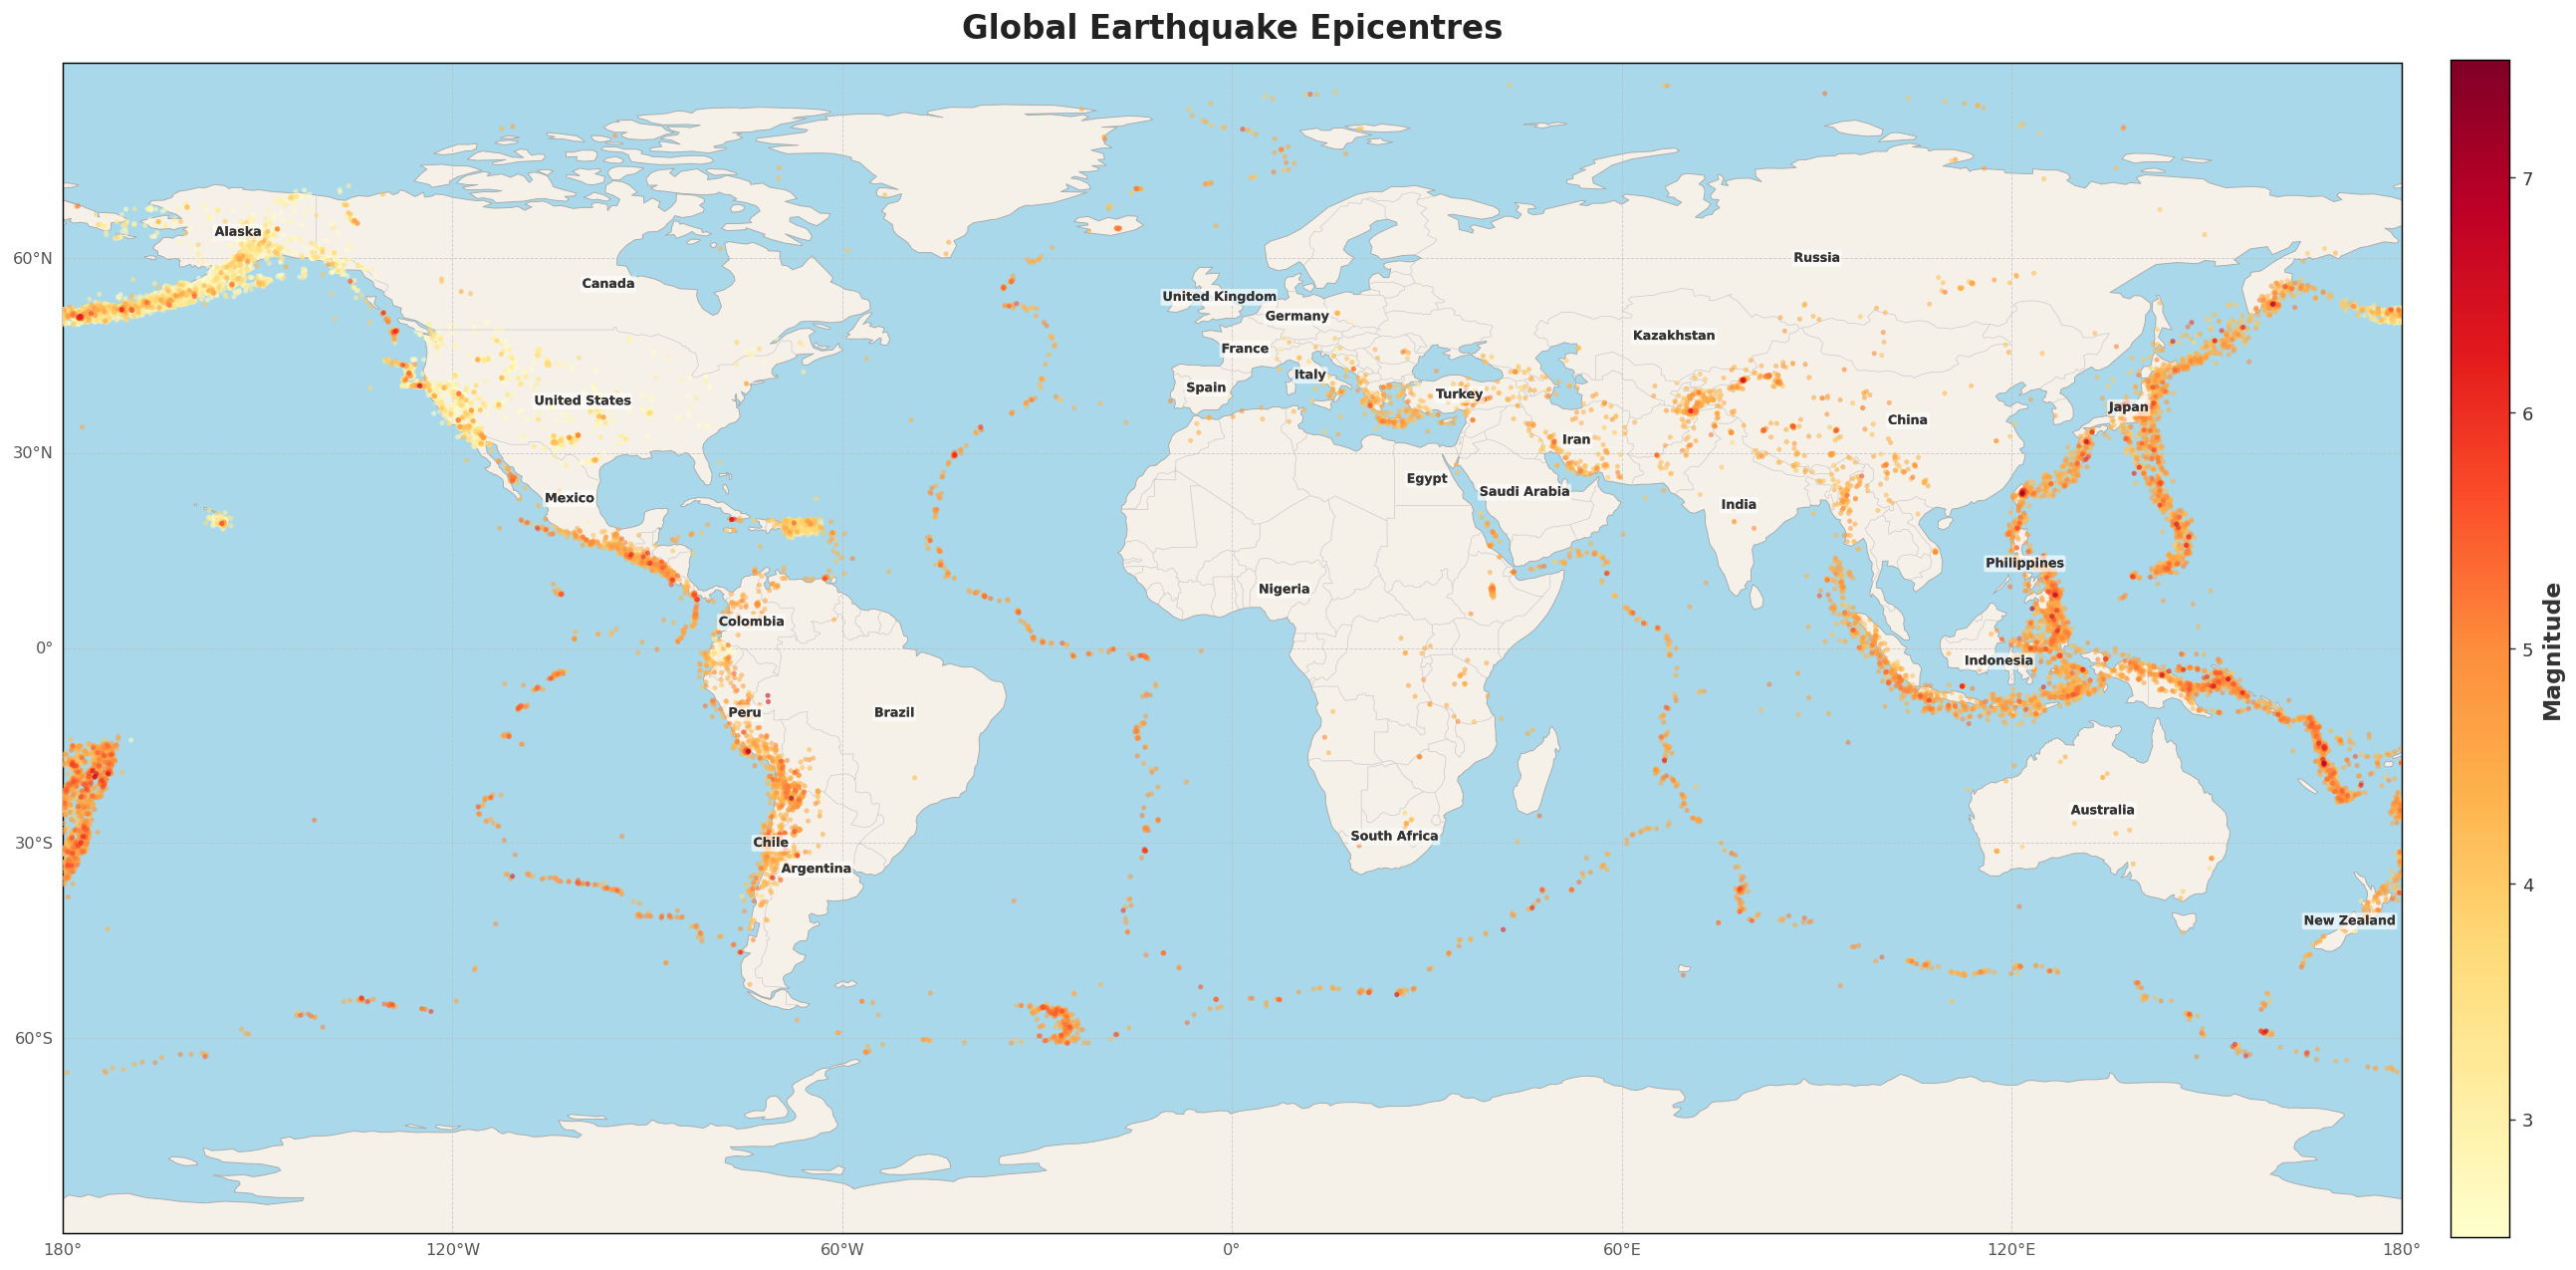

In [16]:
# Chart 1: Hotspot map
generate_and_run_chart("A clean, light Google-Maps-style world map of all earthquake epicentres. Use the PlateCarree projection with a full global extent so it is a standard rectangular world map. Fill the ocean light blue and land light beige, draw thin gray coastlines and country borders, and plot the epicentres colored by magnitude (mag) across its full range with the YlOrRd colormap and a vertical colorbar labeled Magnitude on the right. Label the major countries with their names clearly and legibly, using small bold dark-gray text on a subtle white background box (like the place labels on a map). Add gridlines with latitude/longitude labels and a bold title.")

#### Chart 2: Earthquake Epicentres in Japan

Generated code:
----------------------------------------
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

lon_min, lon_max = 127, 148
lat_min, lat_max = 28, 46
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ocean = cfeature.NaturalEarthFeature(
    'physical', 'ocean', '10m',
    edgecolor='none',
    facecolor='#AED6F1'
)
land = cfeature.NaturalEarthFeature(
    'physical', 'land', '10m',
    edgecolor='none',
    facecolor='#F5F0E8'
)
countries = cfeature.NaturalEarthFeature(
    'cultural', 'admin_0_countries', '10m',
    edgecolor='#AAAAAA',
    facecolor='none',
    linewidth=0.7
)
coastlines = cfeature.NaturalEarthFeature(
    'physical', 'coastline', '10m',
    edgecolor='#8

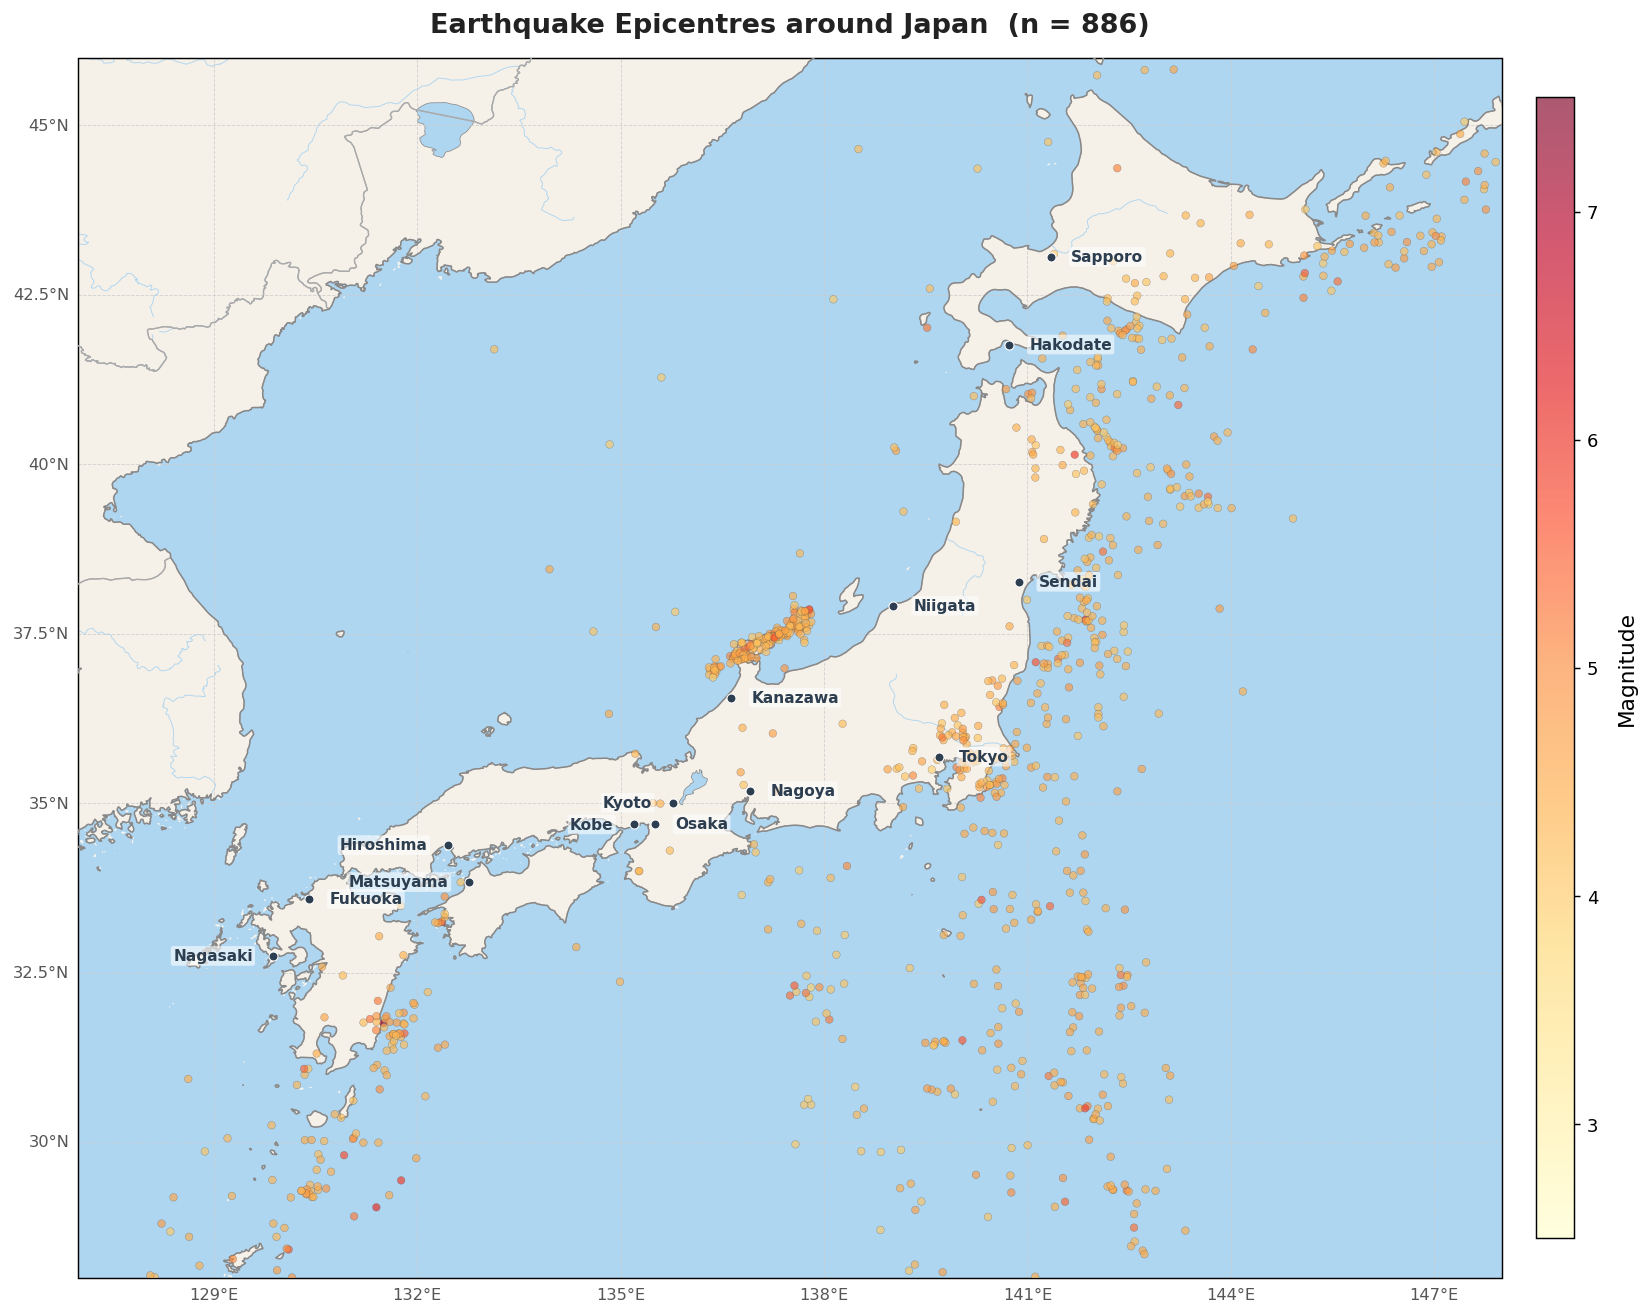

In [ ]:
# Chart 2: Japan epicentres
generate_and_run_chart("Now show the same style of map but zoomed into Japan (about longitude 127 to 148, latitude 28 to 46), plotting only the earthquakes there and labelling the major Japanese cities.")

#### Chart 3: Magnitude Distribution

Generated code:
----------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

counts, bin_edges, patches = ax.hist(
    earthquake_db['mag'],
    bins=25,
    color='#E74C3C',
    edgecolor='white',
    linewidth=0.6,
    alpha=0.85
)

for patch, left_edge in zip(patches, bin_edges[:-1]):
    if left_edge < 2:
        patch.set_facecolor('#3498DB')
    elif left_edge < 4:
        patch.set_facecolor('#2ECC71')
    elif left_edge < 6:
        patch.set_facecolor('#F39C12')
    else:
        patch.set_facecolor('#E74C3C')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498DB', edgecolor='white', label='Micro / Minor  (mag < 2)'),
    Patch(facecolor='#2ECC71', edgecolor='white', label='Minor / Light  (2 ≤ mag < 4)'),
    Patch(facecolor='#F39C12', edgecolor='white', label='Moderate / Strong  (4 ≤ mag < 6)'),
    Patch(facecolor='#E74C3C', edgecolor='white', label='Major / Great  (mag ≥ 6)'),
]
ax.legend(handles=legend_elements, fontsiz

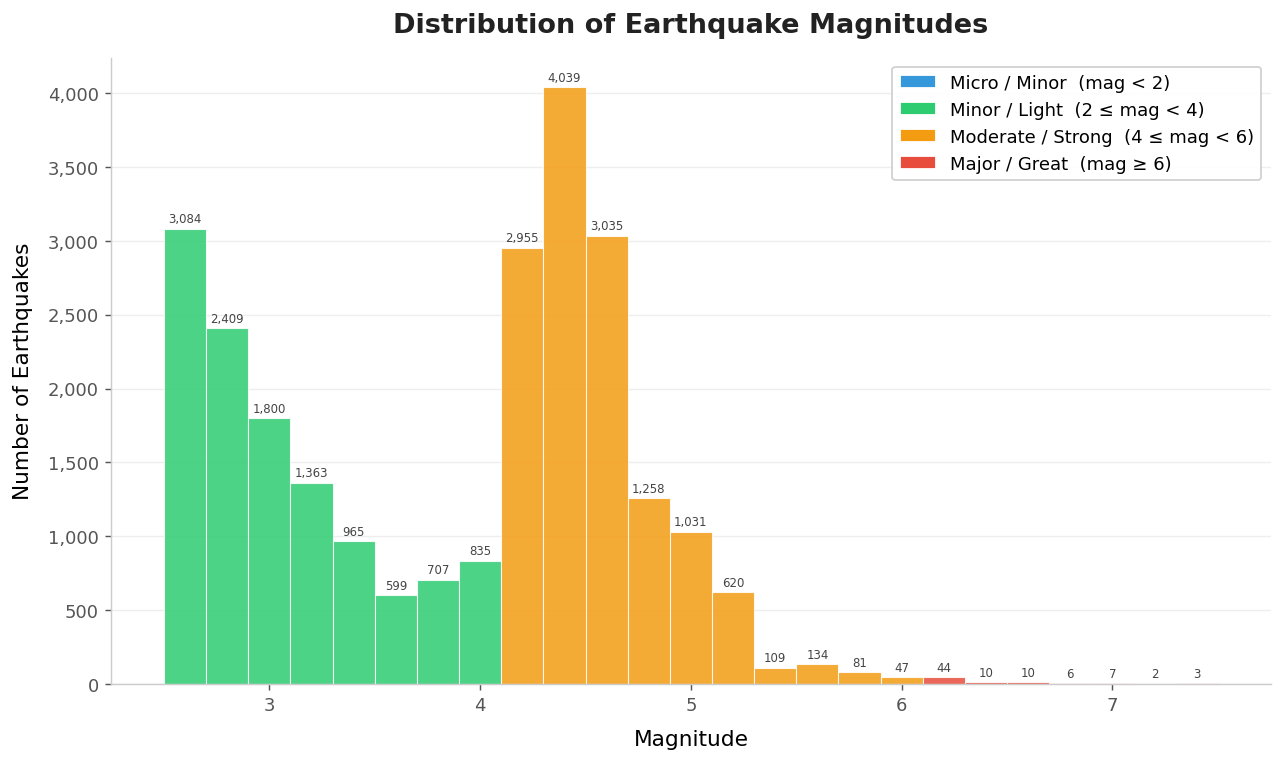

In [17]:
# Chart 3: Magnitude distribution
generate_and_run_chart("A histogram of the earthquake magnitude (mag) column with about 25 bins, to show how many earthquakes fall at each magnitude level.")

#### Chart 4: Top Regions by Earthquake Count

Generated code:
----------------------------------------
region_counts = (
    earthquake_db['region']
    .value_counts()
    .head(12)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.YlOrRd(
    [0.3 + 0.7 * (i / (len(region_counts) - 1)) for i in range(len(region_counts))]
)

bars = ax.barh(
    region_counts.index,
    region_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=0.6,
    height=0.65
)

for bar, count in zip(bars, region_counts.values):
    ax.text(
        bar.get_width() + region_counts.values.max() * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,}',
        va='center',
        ha='left',
        fontsize=10,
        color='#333333',
        fontweight='bold'
    )

ax.set_xlim(0, region_counts.values.max() * 1.15)

ax.set_title(
    'Top 12 Regions by Number of Earthquakes',
    fontsize=15,
    fontweight='bold',
    pad=14,
    color='#222222'
)
ax.set_xlabel('Number of Earthqu

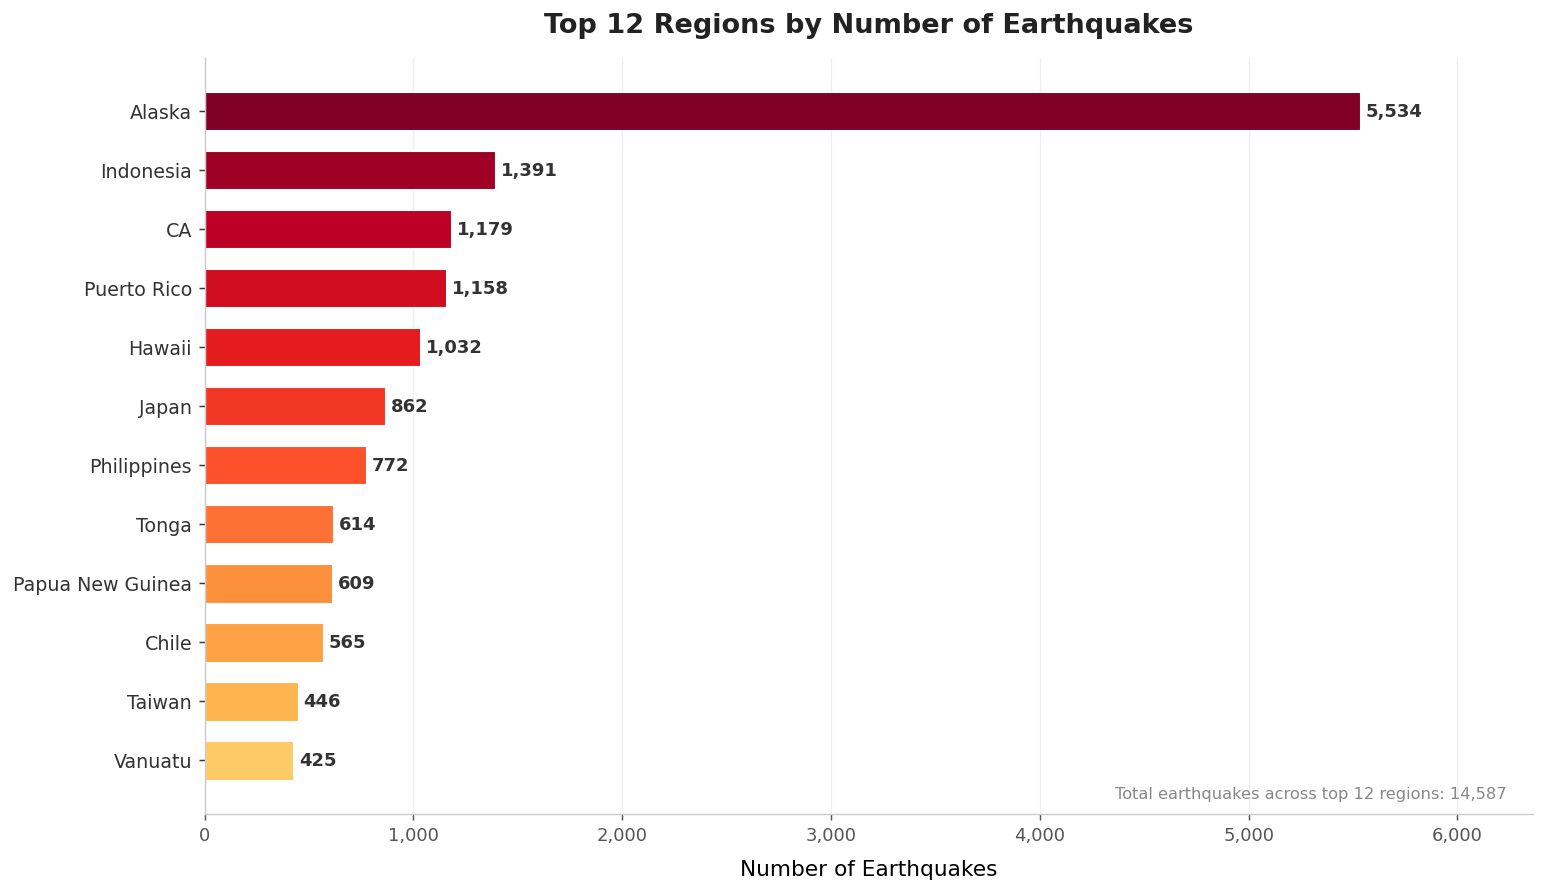

In [19]:
# Chart 4: Top regions
generate_and_run_chart("A horizontal bar chart of the top 12 regions by number of earthquakes, sorted so the region with the most earthquakes is at the top, with the count labeled on each bar.")

#### Chart 5: Average Magnitude by Depth Band

Generated code:
----------------------------------------
depth_order = ['shallow (<70km)', 'intermediate (70-300km)', 'deep (>300km)']

depth_avg = (
    earthquake_db
    .groupby('DepthBand')['mag']
    .mean()
    .reindex(depth_order)
)

fig, ax = plt.subplots(figsize=(9, 6))

bar_colors = ['#2ECC71', '#F39C12', '#E74C3C']

bars = ax.bar(
    depth_avg.index,
    depth_avg.values,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)

for bar, val in zip(bars, depth_avg.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.2f}',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='#333333'
    )

y_min = depth_avg.values.min()
y_max = depth_avg.values.max()
y_padding = (y_max - y_min) * 0.5
ax.set_ylim(
    max(0, y_min - y_padding * 2),
    y_max + y_padding
)

clean_labels = ['Shallow\n(< 70 km)', 'Intermediate\n(70–300 km)', 'Deep\n(> 300 km)'

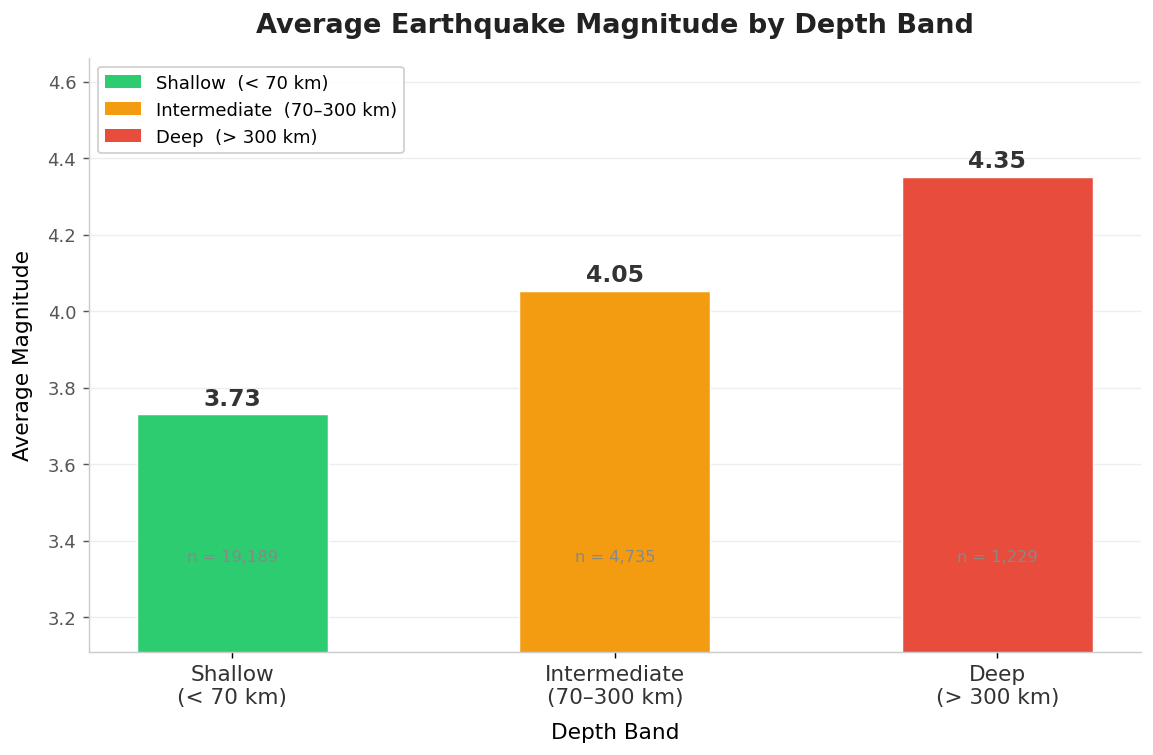

In [20]:
# Chart 5: Magnitude by depth band
generate_and_run_chart("A bar chart of the average earthquake magnitude for each DepthBand, ordered shallow (<70km), intermediate (70-300km), then deep (>300km), with the average magnitude labeled on each bar.")

## Conclusion